In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize'   : (9, 5),
    'figure.dpi'       : 120,
    'axes.titlesize'   : 14,
    'axes.titlepad'    : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
    'ytick.labelsize'  : 10,
    'xtick.labelsize'  : 10,
})
data = r'D:\Unsupervised_lab\retail-unsupervised-lab\data\Online Retail - Online Retail.csv'
df = pd.read_csv(data)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')
df.head()

# DATA UNDERSTANDING

In [32]:
print(f'Shape : {df.shape[0]} rows x {df.shape[1]} columns')
print('Columns :')
print(df.dtypes.to_string())

Shape : 541909 rows x 8 columns
Columns :
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [34]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [35]:
Purchase_by_country = df.groupby('Country')['InvoiceNo'].count().sort_values(ascending=False)
Purchase_by_country.head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: InvoiceNo, dtype: int64

# DATA CLEANING

In [36]:
dup_counts = df.duplicated().sum()
if dup_counts > 0:
    df = df.drop_duplicates()
    print(f'Duplicates Removed. New Shape : {df.shape}')
else:
    print('No Duplicates , Dataset Is Clean.')

Duplicates Removed. New Shape : (536641, 8)


In [37]:
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_pct}).sort_values(by='Missing Values', ascending=False)
print(missing_data.to_string())

             Missing Values  Percentage
CustomerID           135037   25.163377
Description            1454    0.270945
StockCode                 0    0.000000
InvoiceNo                 0    0.000000
Quantity                  0    0.000000
InvoiceDate               0    0.000000
UnitPrice                 0    0.000000
Country                   0    0.000000


In [38]:
before = len(df)
df   = df.dropna(subset=['CustomerID'])
after  = len(df)
print(f'Rows removed (no CustomerID): {before - after}')
print(f'Remaining rows              : {after}')

Rows removed (no CustomerID): 135037
Remaining rows              : 401604


In [39]:
before = len(df)
df   = df[df['Quantity']  > 0]
df   = df[df['UnitPrice'] > 0]
after  = len(df)
print(f'Invalid transactions removed : {before - after}')
print(f'Remaining rows               : {after}')

Invalid transactions removed : 8912
Remaining rows               : 392692


In [40]:
num_cols = ['Quantity', 'UnitPrice']
outliers_summary = []
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary.append({
        'Column': col,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outliers Count': len(outliers),
        'Outliers Percentage': (len(outliers) / len(df)) * 100
    })
outliers_df = pd.DataFrame(outliers_summary)
print(outliers_df.to_string())
print(f'\ntotal outliers detected : {outliers_df["Outliers Count"].sum()}')

      Column  Lower Bound  Upper Bound  Outliers Count  Outliers Percentage
0   Quantity        -13.0         27.0           25616             6.523178
1  UnitPrice         -2.5          7.5           34112             8.686706

total outliers detected : 59728


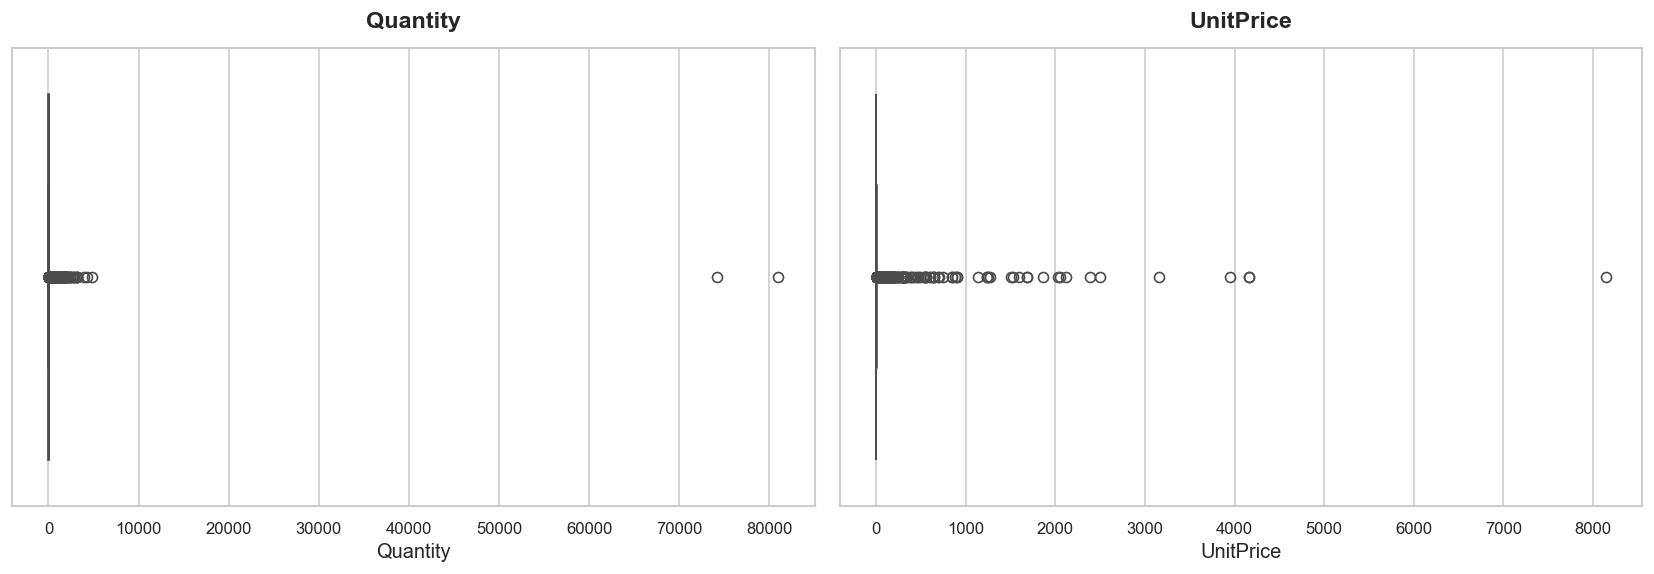

In [41]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Feature Engineering — RFM Calculation

In [ ]:
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# Reference date = 1 day after the last invoice in the dataset
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalSpend',  'sum')
).reset_index()

rfm['Monetary'] = rfm['Monetary'].round(2)

print(f'RFM table shape: {rfm.shape[0]} customers x {rfm.shape[1]} columns')
rfm.head(10)